# Baseline

__En la siguiente celda se muestran las dependencias del código, si está usando uv no debería tener problemas ejecutando el código__

In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
from pyspark.sql.window import Window
from pyspark.sql import functions as F

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient

spark = MinioSparkClient(endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
                        access_key=os.getenv("MINIO_ACCESS_KEY"),
                        secret_key=os.getenv("MINIO_SECRET_KEY"),root_path="pd2/cityenjoyer/",
                        memory = 16,
                        heapsize = 8,
                        num_part = 2000)
spark.connect()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/11 10:42:50 WARN Utils: Your hostname, danpanto-OMEN-Gaming-Laptop-16-ap0xxx, resolves to a loopback address: 127.0.1.1; using 10.8.101.56 instead (on interface wlo1)
26/03/11 10:42:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/danpanto/.ivy2.5.2/cache
The jars for the packages stored in: /home/danpanto/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-81075915-0a1e-40d1-ba56-cca4ec51c618;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central


## Explicación de la baseline:

Para este projecto, independientemente de la variable a predecir utilizaremos el *Moving average forecast*. Basicamente consiste en suponer que el siguiente step es la media de la ventana de entrada. Esta baseline encaja muy bien con nuestros modelos ya que nuestro input siempre son ventanas temporales de tamaño fijo.

El mayor pro que tiene este baseline es que no sufre tanto con datos que cambian su tendencia de forma frecuente, cosa que con los datos de los taxis ocurre con bastante frecuencia.

En la siguiente imagen se puede ver cómo predice con un dataset arbitrario


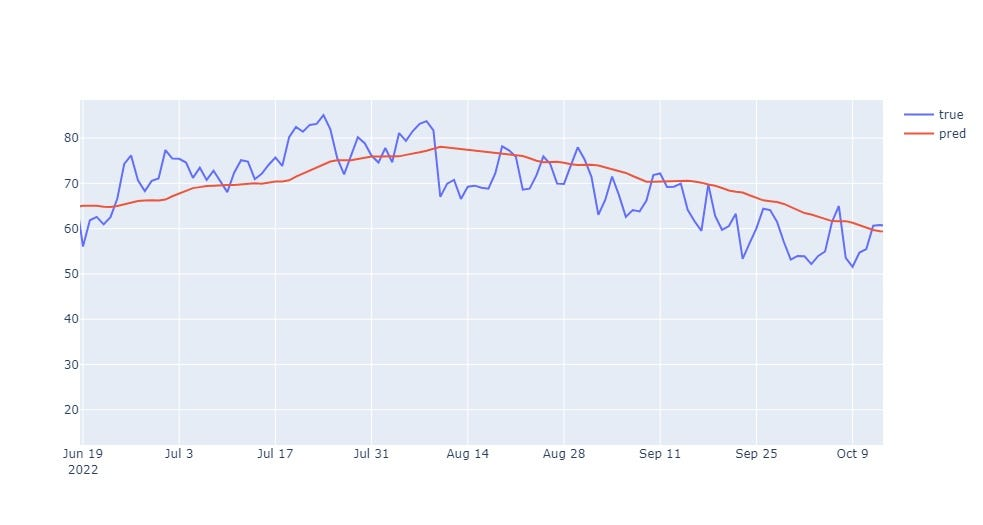

Fuente:
https://towardsdatascience.com/baseline-models-in-time-series-c76d44a826b3/

## Implementación con nuestros datos

### Descarga de los datos

In [2]:
df = spark.read_parquet("data_processed.parquet")

df.show()

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


+--------+------------+-------------------+------+------------+------------------+------------------+------------------+----+---+--------------------+--------------------+--------------------+--------------------+
|VendorID|PULocationID|          timestamp|demand|avg_distance|        avg_amount|          Latitude|         Longitude|hour|dow|            hour_sin|            hour_cos|             dow_sin|             dow_cos|
+--------+------------+-------------------+------+------------+------------------+------------------+------------------+----+---+--------------------+--------------------+--------------------+--------------------+
|       0|           1|2021-01-03 17:00:00|     1|        48.0|            2080.0|40.691829681396484|-74.17400360107422|  17|  1| -0.9659258262890681| -0.2588190451025215|  0.7818314824680298|  0.6234898018587336|
|       0|           1|2021-01-26 13:00:00|     1|         0.0|            1896.0|40.691829681396484|-74.17400360107422|  13|  3|-0.258819045102

### Implementación del baseline

In [7]:
# Definimos una ventana para separar por servicio y zona
window_spec = Window.partitionBy("VendorID", "PULocationID") \
                    .orderBy("timestamp") \
                    .rowsBetween(-5, 0) 

# Aplicamos el baseline
df_forecast = df.withColumn(
    "prediction", 
    F.avg("demand").over(window_spec)
)

df_forecast.select("timestamp", "VendorID", "PULocationID", "demand", "prediction").show()

+-------------------+--------+------------+------+----------+
|          timestamp|VendorID|PULocationID|demand|prediction|
+-------------------+--------+------------+------+----------+
|2021-01-09 12:00:00|       0|           5|     1|       1.0|
|2021-01-11 09:00:00|       0|           5|     1|       1.0|
|2021-01-12 08:00:00|       0|           5|     1|       1.0|
|2021-01-13 08:00:00|       0|           5|     1|       1.0|
|2021-01-14 08:00:00|       0|           5|     1|       1.0|
|2021-01-15 08:00:00|       0|           5|     1|       1.0|
|2021-01-16 10:00:00|       0|           5|     1|       1.0|
|2021-01-17 12:00:00|       0|           5|     1|       1.0|
|2021-01-19 11:00:00|       0|           5|     1|       1.0|
|2021-01-20 19:00:00|       0|           5|     1|       1.0|
|2021-01-21 06:00:00|       0|           5|     1|       1.0|
|2021-01-25 06:00:00|       0|           5|     1|       1.0|
|2021-01-26 06:00:00|       0|           5|     1|       1.0|
|2021-01

### Evaluemos el rendimiento

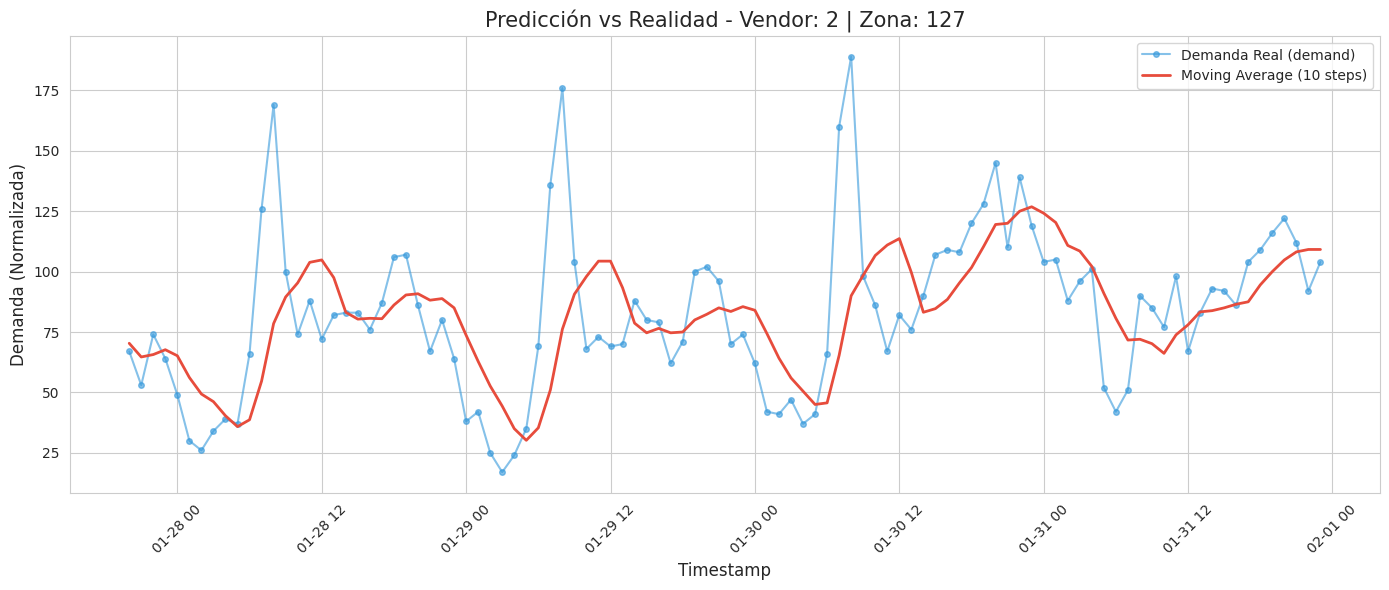

In [8]:
def visualizar_demanda(df_spark, vendor_id, location_id):
    # Filtramos los datos en Spark para que la transferencia a Pandas sea ligera
    df_plot = (df_spark
               .filter((F.col("VendorID") == vendor_id) & (F.col("PULocationID") == location_id))
               .orderBy(F.col("timestamp").desc())
               .limit(100)                     
               .toPandas())

    if df_plot.empty:
        print(f"No hay datos para Vendor {vendor_id} en la zona {location_id}")
        return

    # Configuración del gráfico
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")

    # Graficamos la demanda real
    plt.plot(df_plot['timestamp'], df_plot['demand'], 
             label='Demanda Real (demand)', color='#3498db', alpha=0.6, marker='o', markersize=4)

    # Graficamos la predicción (Media Móvil)
    plt.plot(df_plot['timestamp'], df_plot['prediction'], 
             label='Moving Average (10 steps)', color='#e74c3c', linewidth=2)

    # Personalización
    plt.title(f'Predicción vs Realidad - Vendor: {vendor_id} | Zona: {location_id}', fontsize=15)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('Demanda (Normalizada)', fontsize=12)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

visualizar_demanda(df_forecast, vendor_id=2, location_id=127)